Exploring L5 and L6 MDT neurons

L6 neurons should be slower in activity. Do we see this with ca imaging? Tim was finding evidence of this.
L6 CT neurons should also show more robust task correlates. Fit a glm to each component and test this.

---

In [1]:
import os; path_added = os.path.split(os.path.split(os.getcwd())[0])[0]; os.chdir(path_added); print("Added path:",path_added)
import nwbfun
import plotters
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.ndimage import gaussian_filter

# more packages
import seaborn as sea
import pandas as pd
import matplotlib.gridspec as gridspec
from s2pfuns import baseline_corrected_F

import rootfun as rf # we can import this if our cwd is local
root = rf.dropbox_root(dropbox_folder='timspellman')
nwbpath = os.path.join(root,r"timspellman\Python\John\PySpell\code\Projects\Test Data\t284_SEDS2_L5.nwb")

stat, ops, F, Fneu, spks, iscell, probcell, redcell, probredcell = nwbfun.suite2p_nwb().read_nwb(fpath=nwbpath);
behdict = nwbfun.unwrap().spellmanBeh(nwbpath=nwbpath);
time_around=[10,10] # time around event marker for PETH

# spellman et al., 2021: estimated spike events normalized across the session
spkz = stats.zscore(spks, axis=1)

# smooth the result
spkzsm = gaussian_filter(spkz,sigma=1.5,axes=1)

Added path: c:\Users\johnj\SpellmanLab Dropbox\timspellman\Python\John\PySpell\code


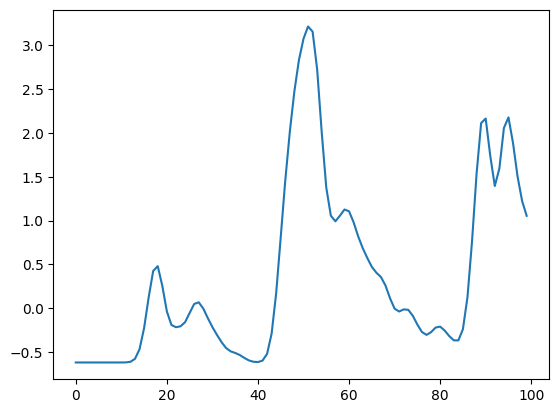

In [2]:
plt.plot(spkzsm[2][0:100])

In [5]:
behdict.keys()

dict_keys(['lickTimesR', 'lickTimesL', 'lickTimesAll', 'trialStartTimes', 'trialEndTimes', 'stimOnTimes', 'stimOffTimes', 'rewardTimesIdxTrials', 'rewardTimes', 'frameTimes', 'lickNumL', 'lickNumR', 'irrelLRs', 'trialLRs', 'setIDs', 'trialCorrect', 'congruentTrial'])

Data exploration with `peth`

`peth` was designed specifically for Spellman lab code. So this inherently requires that you used Tims code to convert your behavioral data to `.mat` files. Once you have done that

Above, we unpacked our suite2p results and behavioral data from the `nwb` file! You could create custom code, or you could use the `peth` function from the `plotters` module

VALIDATION:
    `peth` was validated